<a href="https://colab.research.google.com/github/AakarshDev0p/NLP/blob/main/2403A52262_NLP_14_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 14.2 — Text Classification II
## Building a 1D CNN for Text Classification using PyTorch



## Step 1: Environment Setup
Install and import all required libraries.

In [1]:
# Install dependencies (uncomment if running in Colab)
# !pip install torch torchvision scikit-learn matplotlib seaborn pandas numpy

import os
import re
import string
import urllib.request
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu


---
## Step 2: Data Loading
Load the **SMS Spam Collection** dataset from the UCI ML Repository.

In [2]:
# Download the SMS Spam Collection dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
zip_path = "smsspamcollection.zip"
extract_path = "smsspamcollection"

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete.")

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

# Load into DataFrame
df = pd.read_csv(
    os.path.join(extract_path, 'SMSSpamCollection'),
    sep='\t', header=None, names=['label', 'text'],
    encoding='utf-8'
)

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
df.head(10)

Download complete.
Dataset shape: (5572, 2)

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


---
## Step 3: Text Preprocessing
Clean the raw SMS text — lowercase, strip punctuation, remove numbers and extra spaces.

In [3]:
def preprocess_text(text: str) -> str:
    """Lowercase, remove punctuation and digits, strip extra whitespace."""
    text = text.lower()
    text = re.sub(r'\d+', '', text)                       # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()              # collapse whitespace
    return text

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)

# Encode labels: ham -> 0, spam -> 1
df['label_enc'] = (df['label'] == 'spam').astype(int)

print("Sample preprocessed messages:")
df[['text', 'clean_text', 'label', 'label_enc']].head(5)

Sample preprocessed messages:


,text,clean_text,label,label_enc
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,ham,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,spam,1
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,ham,0
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,ham,0


---
## Step 4: Vocabulary Creation & Sequence Encoding
Build a word-level vocabulary and convert each message to a fixed-length integer sequence.

In [4]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
MAX_SEQ_LEN  = 50    # pad / truncate all sequences to this length
VOCAB_SIZE   = 5000  # keep only the top N most frequent words
PAD_TOKEN    = '<PAD>'
UNK_TOKEN    = '<UNK>'

# Build vocabulary from training corpus
all_words = [word for text in df['clean_text'] for word in text.split()]
word_freq = Counter(all_words)
most_common = word_freq.most_common(VOCAB_SIZE - 2)  # reserve 2 slots

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for idx, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = idx

print(f"Vocabulary size (including PAD/UNK): {len(word2idx)}")

def encode_text(text: str, word2idx: dict, max_len: int) -> list:
    """Convert text to a zero-padded/truncated list of integer indices."""
    tokens = text.split()[:max_len]
    encoded = [word2idx.get(tok, word2idx[UNK_TOKEN]) for tok in tokens]
    # Pad with 0 up to max_len
    encoded += [word2idx[PAD_TOKEN]] * (max_len - len(encoded))
    return encoded

df['encoded'] = df['clean_text'].apply(lambda t: encode_text(t, word2idx, MAX_SEQ_LEN))

# Quick sanity check
print(f"\nEncoded sequence length: {len(df['encoded'].iloc[0])} (should be {MAX_SEQ_LEN})")
print(f"Example: {df['encoded'].iloc[0]}")

Vocabulary size (including PAD/UNK): 5000

Encoded sequence length: 50 (should be 50)
Example: [45, 441, 4009, 779, 699, 668, 64, 10, 1220, 90, 122, 354, 1019, 152, 2729, 1221, 68, 57, 4010, 137, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


---
## Step 5: Train-Test Split
Split the encoded data into 80 % training and 20 % test sets (stratified).

In [5]:
X = np.array(df['encoded'].tolist())     # shape (N, MAX_SEQ_LEN)
y = df['label_enc'].values               # shape (N,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Spam ratio (train): {y_train.mean():.3f}")
print(f"Spam ratio (test) : {y_test.mean():.3f}")

Training samples : 4457
Test samples     : 1115
Spam ratio (train): 0.134
Spam ratio (test) : 0.134


---
## Step 6: Create PyTorch Dataset and DataLoader

In [6]:
class SMSDataset(Dataset):
    """Custom PyTorch Dataset for SMS spam/ham sequences."""

    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        return self.sequences[idx], self.labels[idx]


# ── DataLoader hyperparameters ───────────────────────────────────────────────
BATCH_SIZE = 64

train_dataset = SMSDataset(X_train, y_train)
test_dataset  = SMSDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")

# Verify batch shape
sample_seq, sample_lbl = next(iter(train_loader))
print(f"Sample batch — sequences: {sample_seq.shape}, labels: {sample_lbl.shape}")

Training batches : 70
Test batches     : 18
Sample batch — sequences: torch.Size([64, 50]), labels: torch.Size([64])


---
## Step 7: Build the 1D CNN Model
Architecture:
- **Embedding layer** → dense word vectors
- **Three parallel Conv1D filters** (kernel sizes 2, 3, 4) to capture unigram/bigram/trigram patterns
- **Global max-pooling** over each feature map
- **Dropout** for regularization
- **Fully connected** output layer with sigmoid activation

In [7]:
class TextCNN(nn.Module):
    """
    1D Convolutional Neural Network for binary text classification.

    Architecture:
        Embedding -> Parallel Conv1D (kernel sizes 2,3,4)
        -> Global MaxPool -> Concat -> Dropout -> FC -> Sigmoid
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        num_filters: int,
        kernel_sizes: list,
        num_classes: int,
        dropout: float = 0.5,
        pad_idx: int = 0,
    ):
        super(TextCNN, self).__init__()

        # Embedding layer — padding_idx ensures PAD tokens yield zero vectors
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx,
        )

        # Parallel 1D convolutional feature extractors
        self.convolutions = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k,
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len)  ->  (batch, seq_len, embed_dim)
        embedded = self.embedding(x)

        # Conv1d expects (batch, channels, length)
        embedded = embedded.permute(0, 2, 1)   # (batch, embed_dim, seq_len)

        # Apply each conv, ReLU, then global max-pool
        pooled = []
        for conv in self.convolutions:
            c = torch.relu(conv(embedded))      # (batch, num_filters, L_out)
            c = c.max(dim=2).values             # (batch, num_filters)
            pooled.append(c)

        # Concatenate all filter outputs
        cat = torch.cat(pooled, dim=1)          # (batch, num_filters * len(kernel_sizes))
        cat = self.dropout(cat)

        out = self.fc(cat)                      # (batch, num_classes)
        return out


# ── Model hyperparameters ────────────────────────────────────────────────────
EMBED_DIM     = 64
NUM_FILTERS   = 128
KERNEL_SIZES  = [2, 3, 4]
NUM_CLASSES   = 2
DROPOUT       = 0.5

model = TextCNN(
    vocab_size=len(word2idx),
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

TextCNN(
  (embedding): Embedding(5000, 64, padding_idx=0)
  (convolutions): ModuleList(
    (0): Conv1d(64, 128, kernel_size=(2,), stride=(1,))
    (1): Conv1d(64, 128, kernel_size=(3,), stride=(1,))
    (2): Conv1d(64, 128, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=2, bias=True)
)

Total trainable parameters: 394,882


---
## Step 8: Model Training
Train the 1D CNN using **Cross-Entropy Loss** and the **Adam** optimizer.

In [8]:
# ── Training hyperparameters ─────────────────────────────────────────────────
EPOCHS    = 10
LR        = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
train_accs   = []


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)          # (batch, num_classes)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * sequences.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += sequences.size(0)

    return total_loss / total, correct / total


print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>11}")
print("-" * 33)

for epoch in range(1, EPOCHS + 1):
    loss, acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_losses.append(loss)
    train_accs.append(acc)
    print(f"{epoch:>6} {loss:>12.4f} {acc:>10.4f}")

print("\nTraining complete.")

 Epoch   Train Loss   Train Acc
---------------------------------
     1       0.3553     0.8773
     2       0.1537     0.9529
     3       0.0849     0.9751
     4       0.0568     0.9834
     5       0.0351     0.9912
     6       0.0223     0.9944
     7       0.0206     0.9948
     8       0.0193     0.9935
     9       0.0131     0.9973
    10       0.0090     0.9982

Training complete.


### Training Loss & Accuracy Curves

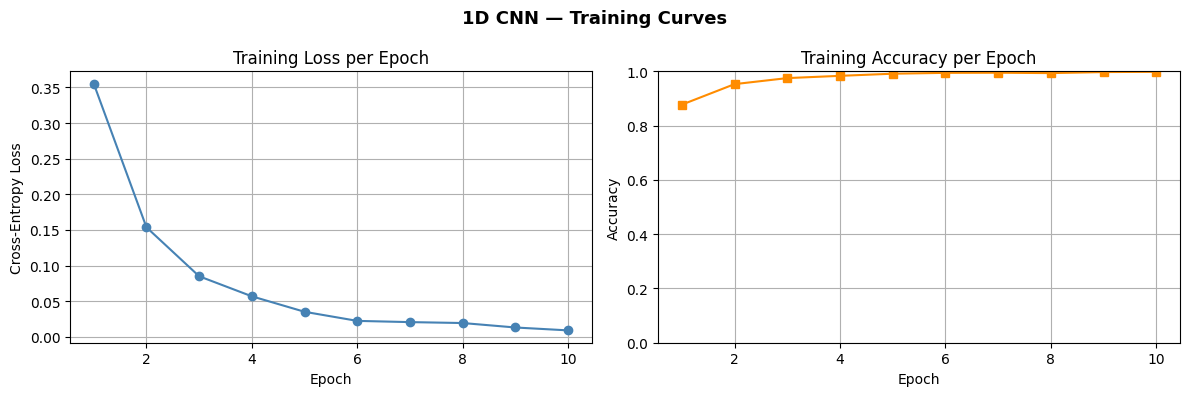

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS + 1), train_losses, marker='o', color='steelblue')
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True)

axes[1].plot(range(1, EPOCHS + 1), train_accs, marker='s', color='darkorange')
axes[1].set_title('Training Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(True)

plt.suptitle('1D CNN — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9: Model Evaluation
Evaluate the trained CNN on the held-out test set.

In [10]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(device)
            outputs   = model(sequences)
            preds     = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


cnn_preds, true_labels = evaluate(model, test_loader, DEVICE)

# ── Metrics ──────────────────────────────────────────────────────────────────
cnn_acc  = accuracy_score(true_labels, cnn_preds)
cnn_prec = precision_score(true_labels, cnn_preds, zero_division=0)
cnn_rec  = recall_score(true_labels, cnn_preds, zero_division=0)
cnn_f1   = f1_score(true_labels, cnn_preds, zero_division=0)

print("=" * 45)
print(" 1D CNN — Test Set Evaluation")
print("=" * 45)
print(f"  Accuracy  : {cnn_acc:.4f}")
print(f"  Precision : {cnn_prec:.4f}")
print(f"  Recall    : {cnn_rec:.4f}")
print(f"  F1-Score  : {cnn_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(true_labels, cnn_preds,
                             target_names=['Ham (0)', 'Spam (1)']))

 1D CNN — Test Set Evaluation
  Accuracy  : 0.9776
  Precision : 0.9627
  Recall    : 0.8658
  F1-Score  : 0.9117

Detailed Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.99       966
    Spam (1)       0.96      0.87      0.91       149

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



### Confusion Matrix — 1D CNN

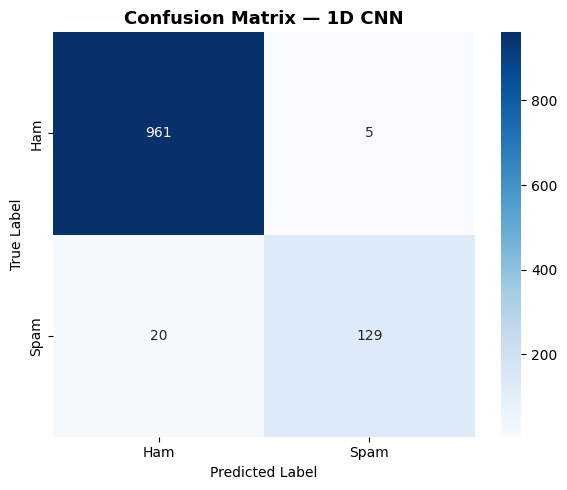

In [11]:
cm_cnn = confusion_matrix(true_labels, cnn_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_cnn, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam'],
)
plt.title('Confusion Matrix — 1D CNN', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

---
## Step 10: Result Analysis — CNN vs. Naïve Bayes Baseline
Train a Multinomial Naïve Bayes classifier on raw Bag-of-Words features and compare with the CNN.

In [12]:
# Re-split the raw cleaned text (same indices as encoded split)
texts = df['clean_text'].values
labels_raw = df['label_enc'].values

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    texts, labels_raw, test_size=0.2, random_state=SEED, stratify=labels_raw
)

# Vectorize with BoW
vectorizer = CountVectorizer(max_features=VOCAB_SIZE)
X_bow_train = vectorizer.fit_transform(X_text_train)
X_bow_test  = vectorizer.transform(X_text_test)

# Train Naïve Bayes
nb = MultinomialNB()
nb.fit(X_bow_train, y_text_train)
nb_preds = nb.predict(X_bow_test)

nb_acc  = accuracy_score(y_text_test, nb_preds)
nb_prec = precision_score(y_text_test, nb_preds, zero_division=0)
nb_rec  = recall_score(y_text_test, nb_preds, zero_division=0)
nb_f1   = f1_score(y_text_test, nb_preds, zero_division=0)

print("=" * 45)
print(" Naïve Bayes Baseline — Test Set Evaluation")
print("=" * 45)
print(f"  Accuracy  : {nb_acc:.4f}")
print(f"  Precision : {nb_prec:.4f}")
print(f"  Recall    : {nb_rec:.4f}")
print(f"  F1-Score  : {nb_f1:.4f}")

 Naïve Bayes Baseline — Test Set Evaluation
  Accuracy  : 0.9821
  Precision : 0.9640
  Recall    : 0.8993
  F1-Score  : 0.9306


### Side-by-Side Metric Comparison

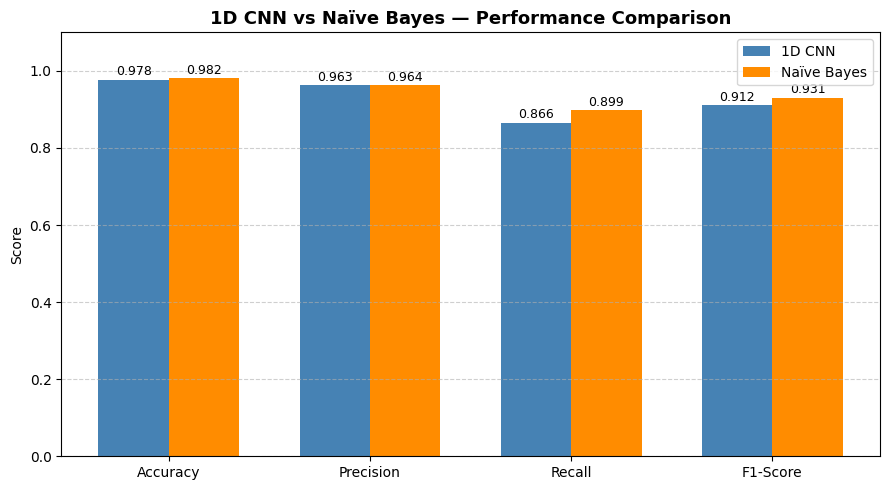


Comparison Table:
   Metric 1D CNN Naïve Bayes
 Accuracy 0.9776      0.9821
Precision 0.9627      0.9640
   Recall 0.8658      0.8993
 F1-Score 0.9117      0.9306


In [13]:
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cnn_vals = [cnn_acc, cnn_prec, cnn_rec, cnn_f1]
nb_vals  = [nb_acc,  nb_prec,  nb_rec,  nb_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, cnn_vals, width, label='1D CNN',       color='steelblue')
bars2 = ax.bar(x + width/2, nb_vals,  width, label='Naïve Bayes',  color='darkorange')

ax.set_ylabel('Score')
ax.set_title('1D CNN vs Naïve Bayes — Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
comparison_df = pd.DataFrame({
    'Metric': metrics,
    '1D CNN': [f"{v:.4f}" for v in cnn_vals],
    'Naïve Bayes': [f"{v:.4f}" for v in nb_vals],
})
print("\nComparison Table:")
print(comparison_df.to_string(index=False))

### Confusion Matrix — Naïve Bayes Baseline

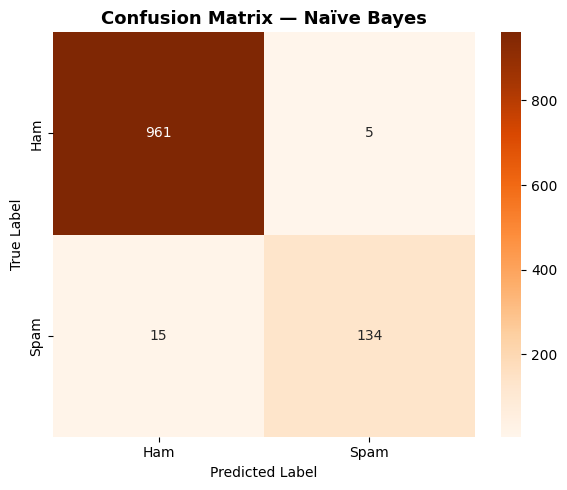

In [14]:
cm_nb = confusion_matrix(y_text_test, nb_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam'],
)
plt.title('Confusion Matrix — Naïve Bayes', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()